In [21]:
!pip install streamlit pyngrok joblib

In [22]:
import pandas as pd   # 라이브러리 불러오기
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [23]:
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"

df = pd.read_csv(url)

# 컬럼명 앞뒤 공백 제거
df.columns = df.columns.str.strip()

# 결측치 제거
df = df.dropna()

print(df.columns.tolist())
print(df.shape)

['Country', 'Year', 'Status', 'Life expectancy', 'Adult mortality', 'Infant deaths', 'Alcohol', 'Percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'Under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'Thinness 1-19 years', 'Thinness 5-9 years', 'Income composition of resources', 'Schooling']
(1649, 22)


In [24]:
features = [
    'Adult mortality',
    'BMI',
    'GDP',
    'Alcohol'
]

target = 'Life expectancy'

In [25]:
X = df[features]        # 데이터 분리
y = df[target]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
X_train = X_train_full.sample(      #훈련 데이터 50개 샘플 추출
    n=50,
    random_state=42
)

y_train = y_train_full.loc[X_train.index]

print(X_train.shape)

(50, 4)


In [27]:
linear_model = Pipeline([   #liner 모델
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

linear_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

In [28]:
poly_model = Pipeline([               #poly 모델
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('regressor', LinearRegression())
])

poly_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(degree=3)),
                ('regressor', LinearRegression())])

In [29]:
ridge_model = Pipeline([    # ridge 모델
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('regressor', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(degree=3)),
                ('regressor', Ridge())])

In [30]:
joblib.dump(linear_model, "linear_model.pkl")     # 모델 저장

joblib.dump(poly_model, "poly_model.pkl")

joblib.dump(ridge_model, "ridge_model.pkl")

print("모델 저장 완료")

모델 저장 완료


In [31]:
models = {                  # 성능 비교 테이블 생성
    "Linear": linear_model,
    "Poly": poly_model,
    "Ridge": ridge_model
}

results = []

for name, model in models.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    if name == "Linear":
        complexity = len(features)
    else:
        complexity = model.named_steps['poly'].fit_transform(
            X_train
        ).shape[1]

    results.append([
        name,
        train_r2,
        test_r2,
        train_mse,
        test_mse,
        complexity
    ])

result_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Train R2',
        'Test R2',
        'Train MSE',
        'Test MSE',
        'Complexity'
    ]
)

result_df

,Model,Train R2,Test R2,Train MSE,Test MSE,Complexity
0,Linear,0.733584,0.579432,29.216463,29.869771,4
1,Poly,0.961695,-476.580782,4.200751,33918.973712,35
2,Ridge,0.923786,0.123047,8.357963,62.283377,35


In [46]:
%%writefile app.py

import streamlit as st # app.py 생성
import pandas as pd
import joblib

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"

df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df = df.dropna()

features = [
    'Adult mortality',
    'BMI',
    'GDP',
    'Alcohol'
]

target = 'Life expectancy'

linear_model = joblib.load("linear_model.pkl")
poly_model = joblib.load("poly_model.pkl")
ridge_model = joblib.load("ridge_model.pkl")

models = {
    "Linear": linear_model,
    "Poly": poly_model,
    "Ridge": ridge_model
}

st.title("Life Expectancy Prediction Dashboard")

st.sidebar.header("Input Features")

adult = st.sidebar.slider(
    "Adult mortality",
    float(df['Adult mortality'].min()),
    float(df['Adult mortality'].max()),
    float(df['Adult mortality'].mean())
)

bmi = st.sidebar.slider(
    "BMI",
    float(df['BMI'].min()),
    float(df['BMI'].max()),
    float(df['BMI'].mean())
)

gdp = st.sidebar.slider(
    "GDP",
    float(df['GDP'].min()),
    float(df['GDP'].max()),
    float(df['GDP'].mean())
)

alcohol = st.sidebar.slider(
    "Alcohol",
    float(df['Alcohol'].min()),
    float(df['Alcohol'].max()),
    float(df['Alcohol'].mean())
)

selected_model = st.selectbox(
    "Choose Model",
    ["Linear", "Poly", "Ridge"]
)

input_df = pd.DataFrame({
    'Adult mortality':[adult],
    'BMI':[bmi],
    'GDP':[gdp],
    'Alcohol':[alcohol]
})

prediction = models[selected_model].predict(input_df)[0]

st.metric(
    "Predicted Life Expectancy",
    f"{prediction:.2f} years"
)

X = df[features]
y = df[target]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train = X_train_full.sample(
    n=50,
    random_state=42
)

y_train = y_train_full.loc[X_train.index]

results = []

for name, model in models.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    if name == "Linear":
        complexity = len(features)
    else:
        complexity = model.named_steps['poly'].fit_transform(X_train).shape[1]

    results.append([
        name,
        train_r2,
        test_r2,
        train_mse,
        test_mse,
        complexity
    ])

result_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Train R2',
        'Test R2',
        'Train MSE',
        'Test MSE',
        'Complexity'
    ]
)

st.subheader("Model Performance Comparison")

st.dataframe(result_df)

fig, ax = plt.subplots()

ax.bar(
    result_df["Model"],
    result_df["Test R2"]
)

ax.set_ylabel("Test R2")

st.pyplot(fig)

Overwriting app.py


In [48]:
!streamlit run app.py &>/content/log.txt & #streamlit 실행

In [34]:
!pip install pyngrok #ngrok 설치

In [36]:
!ngrok config add-authtoken 3EkTnttbaOfN51Nz4O0VXvdRlJo_7k47Yh1hBVFfYAvf6X7h1

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [49]:
from pyngrok import ngrok       #ngrok 연결

public_url = ngrok.connect(8503)

print(public_url)

NgrokTunnel: "https://shorty-sushi-crusader.ngrok-free.dev" -> "http://localhost:8503"


In [50]:
!cat /content/log.txt



2026-06-06 05:05:37.196 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.236.12:8501



In [52]:
from google.colab import files

files.download('app.py')
files.download('linear_model.pkl')
files.download('poly_model.pkl')
files.download('ridge_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

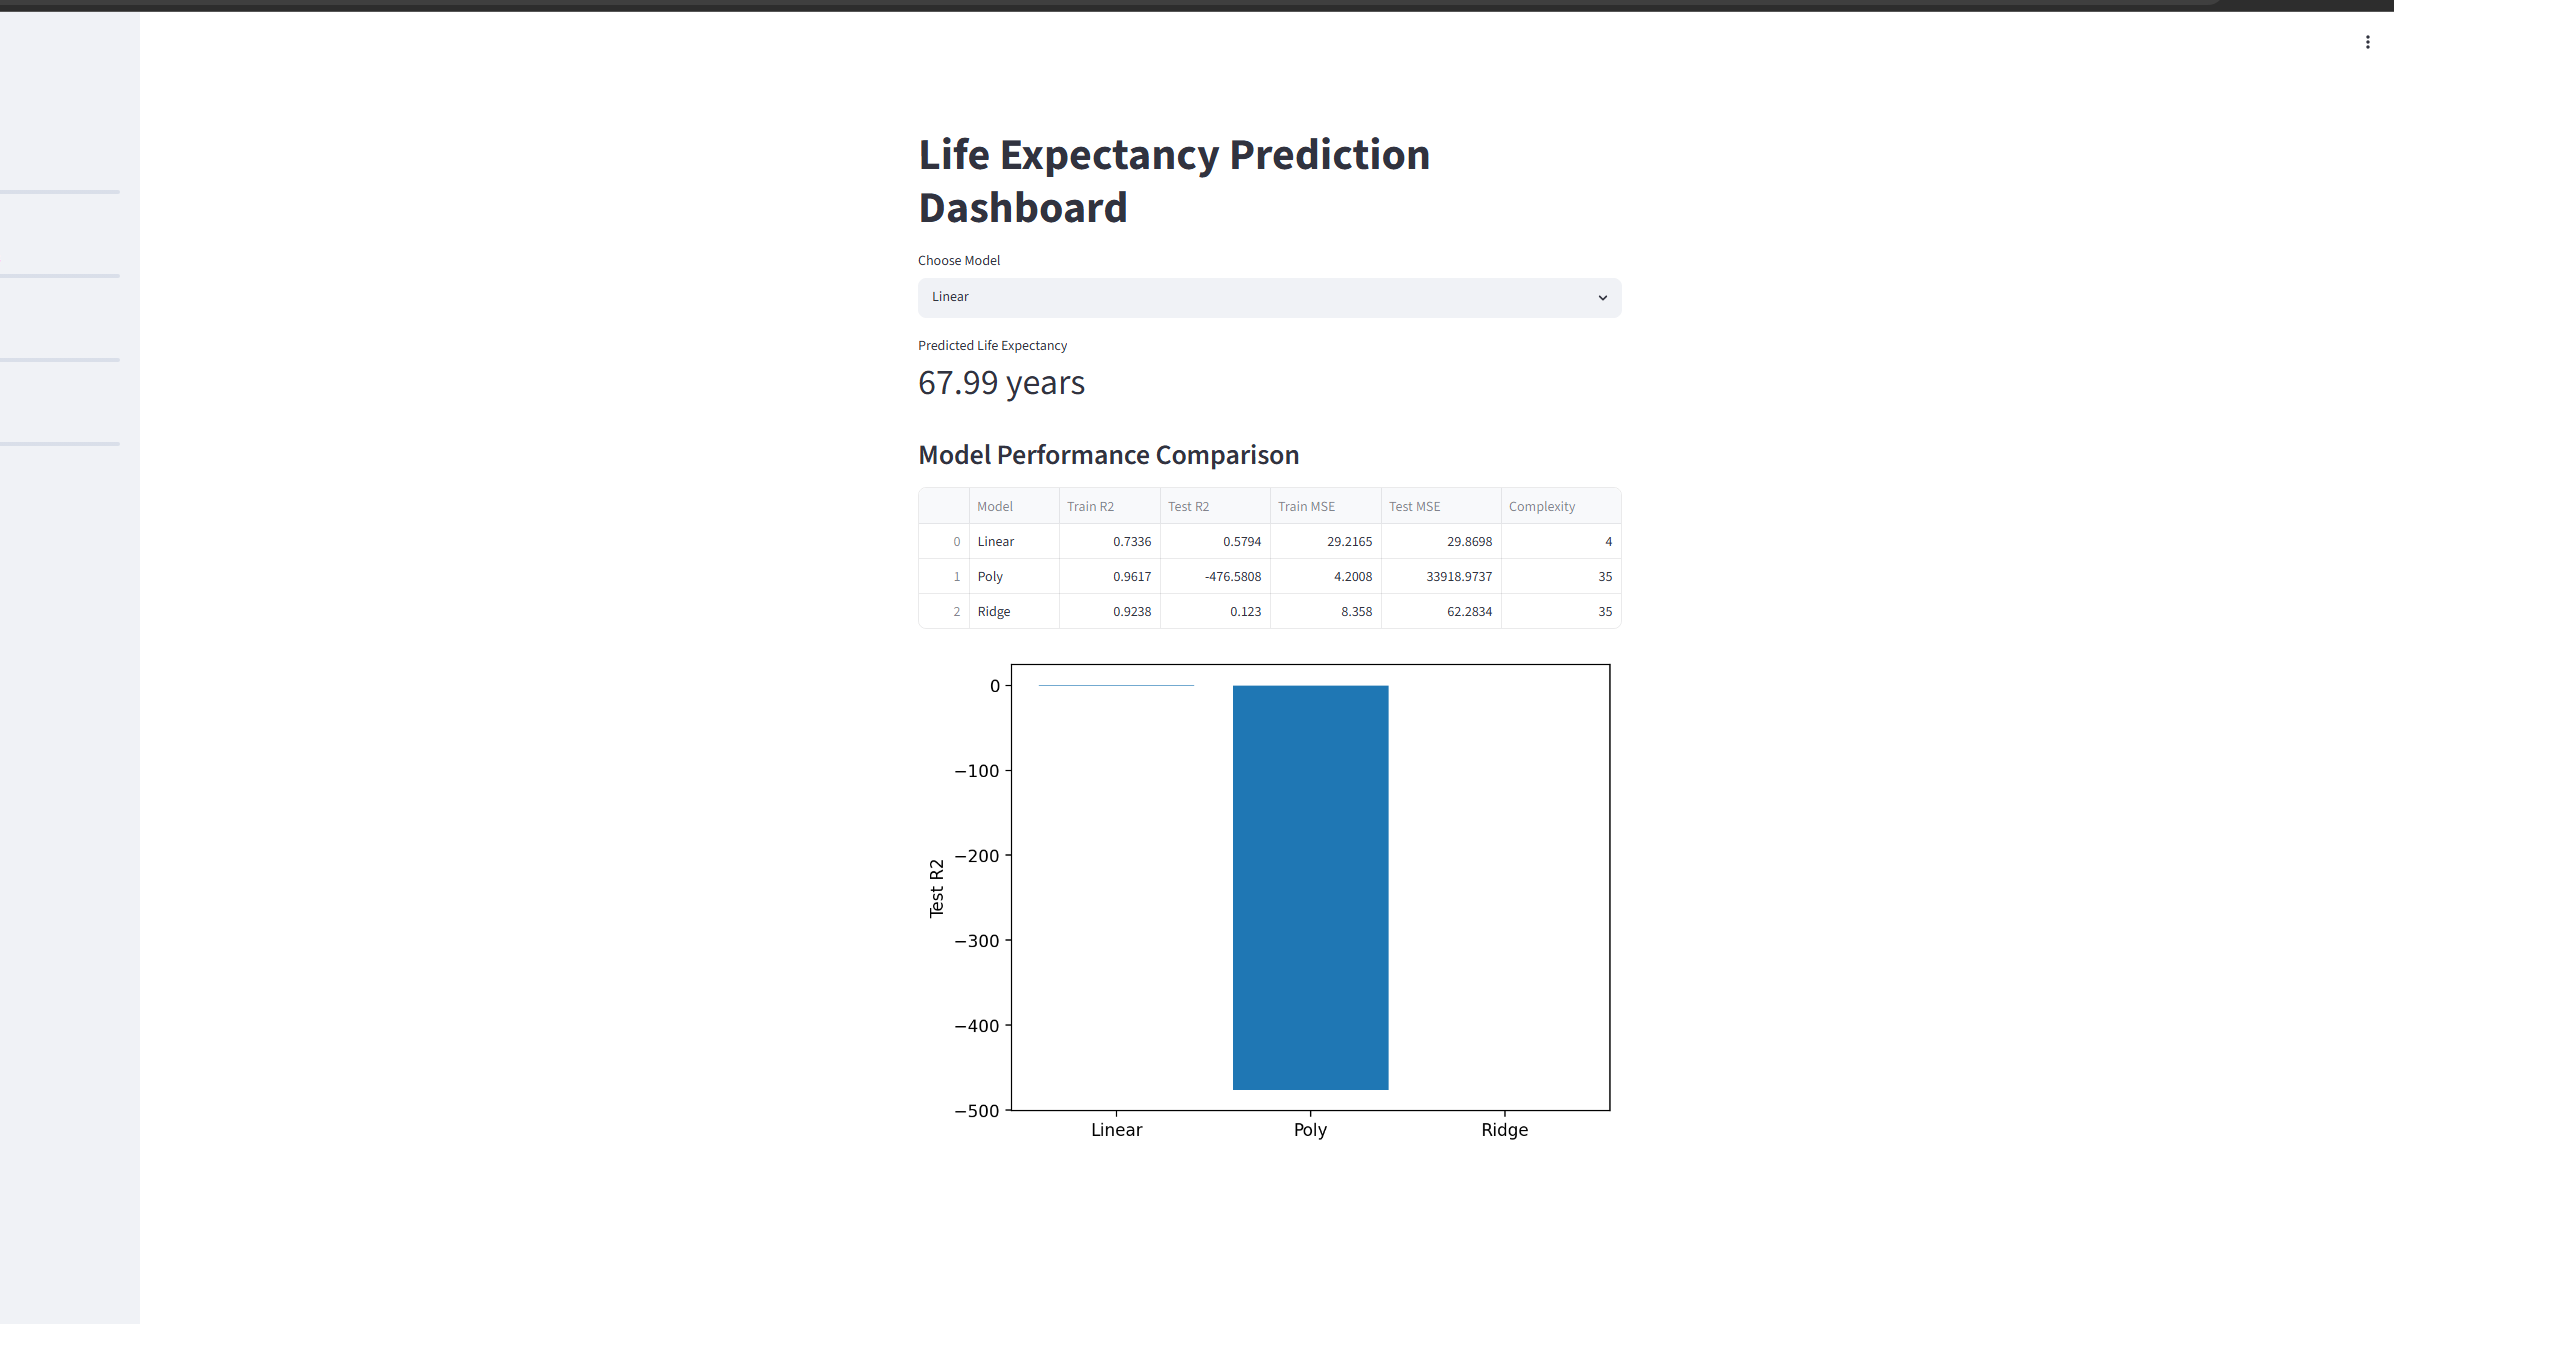